In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

import warnings 
warnings.filterwarnings("ignore") #ignore some matplotlib warnings

import numpy as np

from mpi4py import MPI

from triqs.plot.mpl_interface import plt, oplot, oplotr, oploti
plt.rcParams["figure.figsize"] = (6,4) # set default size for all figures

# One-boson retarded interaction

This tutorial shows how to include a retarded (dynamical) interaction in a `triqs_xca` calculation. It is adapted from the [TRIQS/ctseg tutorial of the same name](https://triqs.github.io/ctseg/latest/tutorials/One-boson%20retarded%20interaction.html), which solves the model below with continuous-time quantum Monte Carlo, so that the two solvers can be compared directly.

The model is the smallest one with a retarded interaction: a single fermionic level (0) hybridized with one bath level (1) and coupled linearly to one bosonic mode,

$$
H = \epsilon_0 c^\dagger_0 c_0 + \epsilon_1 c^\dagger_1 c_1 
+ V (c^\dagger_1 c_0 + c^\dagger_0 c_1)
+ g (b + b^\dagger) c^\dagger_0 c_0
+ \omega_0 b^\dagger b
\, .
$$

Integrating out the bath level and the boson leaves an action for the level 0 alone,

$$
\mathcal{S} = 
\int_0^\beta d\tau \, H_{0}(\tau) 
+ 
\iint_0^\beta d\tau d\tau' \, c_0^\dagger(\tau) \Delta(\tau - \tau') c_0(\tau')
+
\frac{1}{2} \iint_0^\beta d\tau d\tau' \, n_0(\tau) \, \mathcal{U}(\tau - \tau') \, n_0(\tau')
\, ,
$$

with $H_{0} = \epsilon_0 c^\dagger_0 c_0$, $n_0 = c^\dagger_0 c_0$, the hybridization function 
$\Delta(i\nu_n) = \frac{V^2}{i\nu_n - \epsilon_1}$,
and the retarded interaction $\mathcal{U}(i\omega_n) = - 2 g^2 \frac{\omega_0}{\omega_0^2 - (i\omega_n)^2} \,.$

`triqs_xca` expands in the hybridization and in the retarded interaction on the same footing: the expansion order counts hybridization lines and interaction lines together in the pseudo-particle self-energy diagrams. Below we compare the results of the first four expansion orders (the first two being the non-crossing and one-crossing approximations, NCA and OCA) for the single particle Green's function $G_0(\tau) = - \langle \mathcal{T} c_0(\tau) c_0^\dagger \rangle$ and the density correlator $\chi(\tau) = \langle \mathcal{T} n_0(\tau) n_0 \rangle$ with exact diagonalization of $H$. The bosonic Hilbert space is infinite, so the diagonalization works in a truncated boson number space and is converged with respect to the truncation.

## Solving the retarded action with `triqs_xca`

**1.** We start from the parameters of the model. The bosonic mode frequency $\omega_0 = 1$ is the unit of energy and the coupling $g = 1/2$ is in the intermediate coupling regime (at the stronger coupling $g = 1$ of the ctseg tutorial the order-by-order convergence is slow). The chemical potential $\mu = -g^2/\omega_0$ compensates the polaron shift of the level, so that $\epsilon_0 = 0$ corresponds to half filling.

In [2]:
eps0, eps1, V, g, omega0 = -0.1, +0.1, 0.25, 0.5, 1.
mu = -g**2 / omega0 # For half-filling at eps0 = 0
beta = 10.

<p></p>

**2.** Next we construct a solver for the local Hamiltonian $H_0 - \mu n_0$. The imaginary time response functions are represented in the Discrete Lehmann Representation (DLR), with accuracy `eps` and frequency cut-off `w_max` chosen such that the spectra of $\Delta$, $\mathcal{U}$ and $G_0$ are covered.

In [3]:
from triqs.operators import n
from triqs_xca import BlockSparseSolver as Solver

S = Solver(
    H_loc=(eps0 - mu) * n('0', 0),
    beta=beta, # Inverse temperature
    gf_struct=[('0', 1)], # Green's function structure 1st index: name, 2nd index: dimension of subspace
    eps=1e-10, # Accuracy of Discrete Lehmann Representation (DLR) used for imaginary time response functions
    w_max=5.0, # DLR frequency cut-off (the spectrum of the model must be in the range [-w_max, +w_max])
    )

Starting run with 8 MPI rank(s) at : 2026-09-29 22:07:06.496281


____  ____________     _____
\   \/  /\_   ___ \   /  _  \
 \     / /    \  \/  /  /_\  \
 /     \ \     \____/    |    \
/___/\  \ \______  /\____|__  /
      \_/        \/         \/  [github.com/TRIQS/xca]

beta = 10.0, w_max = 5.0, eps = 1e-10, N_DLR = 24
AtomDiagReal: dim 2 with 2 subspaces dims [1] freq [2] E min/max +0.00E+00/+1.50E-01


<p></p>

**3.** The hybridization function is stored in `S.Delta_tau` on the DLR imaginary time mesh of the solver. We set it from its Matsubara frequency expression $\Delta(i\nu_n) = \frac{V^2}{i\nu_n - \epsilon_1}$,

In [4]:
from triqs.gfs import make_gf_dlr_imfreq, make_gf_dlr_imtime, inverse, iOmega_n

Delta_iw = make_gf_dlr_imfreq(S.Delta_tau['0'])
Delta_iw << V**2 * inverse(iOmega_n - eps1)
S.Delta_tau['0'] << make_gf_dlr_imtime(Delta_iw);

<p></p>

**4.** The retarded interaction is a bosonic function of imaginary time, so we construct it on a bosonic DLR mesh with the same $\beta$, `eps` and `w_max` as the solver, again from its Matsubara frequency expression $\mathcal{U}(i\omega_n) = - 2 g^2 \frac{\omega_0}{\omega_0^2 - (i\omega_n)^2}$.

Retarded interactions are passed to the solver with `set_dynamic_interactions`, as a list of operators $O_i$ together with a matrix valued kernel $D_{ij}(\tau)$, which the solver interprets as the action term $\iint_0^\beta d\tau d\tau' \sum_{ij} O_i^\dagger(\tau) \, D_{ij}(\tau - \tau') \, O_j(\tau')$ without a factor $\frac{1}{2}$. Comparing with the action $\mathcal{S}$ above, the single operator $O = n_0$ therefore comes with the kernel $D(\tau) = \frac{1}{2} \mathcal{U}(\tau)$.

In [5]:
from triqs.gfs import Gf, MeshDLRImTime

b_mesh = MeshDLRImTime(beta=beta, statistic='Boson', eps=S.mesh_tau.eps, w_max=S.mesh_tau.w_max, symmetrize=False)

U_tau = Gf(mesh=b_mesh, target_shape=[1, 1])
U_iw = make_gf_dlr_imfreq(U_tau)
U_iw << -2 * g**2 * omega0 * inverse(omega0**2 - iOmega_n*iOmega_n)
U_tau << make_gf_dlr_imtime(U_iw)

S.set_dynamic_interactions(dynint_ops=[n('0', 0)], dynint_tau=0.5 * U_tau)

<p></p>

**5.** Finally we run the solver for expansion orders one to four, and evaluate the density correlator $\chi(\tau) = \langle \mathcal{T} n_0(\tau) n_0 \rangle$ at the same order with `eval_one_time_correlator`. For plotting, the DLR results are interpolated onto a dense imaginary time mesh.

The number of diagrams grows rapidly with the order, and the fourth order dominates the run time by far. The diagram evaluation is MPI parallel, and this notebook was executed with eight MPI ranks.

In [6]:
from triqs.gfs import make_gf_imtime

n_tau = 401
results = {}

for order in [1, 2, 3, 4]:
    S.solve(max_order=order, tol=1e-6, maxiter=50)
    chi_tau = -S.eval_one_time_correlator(S.G, max_order=order, ops_tau=[n('0', 0)], ops_0=[n('0', 0)]) # returns -<T n(tau) n(0)>
    results[order] = dict(
        G_tau=make_gf_imtime(S.G_tau['0'], n_tau=n_tau), 
        chi_tau=make_gf_imtime(chi_tau, n_tau=n_tau))

Hybridization: using DLR expansion with N_poles = 24
iter = 1, diff_G = 5.16E-01, Z-1 = -1.88E-13, eta = 1.59E-01
iter = 2, diff_G = 9.77E-02, Z-1 = -3.69E-13, eta = 1.97E-01
iter = 3, diff_G = 1.43E-02, Z-1 = -5.22E-14, eta = 2.02E-01
iter = 4, diff_G = 1.56E-03, Z-1 = -5.33E-15, eta = 2.03E-01
iter = 5, diff_G = 9.97E-05, Z-1 = -5.55E-16, eta = 2.03E-01
iter = 6, diff_G = 4.28E-06, Z-1 = +2.22E-16, eta = 2.03E-01
iter = 7, diff_G = 1.33E-07, Z-1 = +0.00E+00, eta = 2.03E-01
Converged after 7 iterations with diff_G = 1.33E-07 < tol = 1.00E-06

Timing:                       incl.     excl.
----------------------------------------------------
Adapol hybridization fit:     0.000     0.000   0.3% |
AtomDiag Init:                0.001     0.001   2.0% ||
DiagramEvaluator Init:        0.001     0.001   1.6% ||
Dyson:                        0.008     0.001   1.7% ||
 Setup:                       0.005     0.005  10.5% |---|
 Solve:                       0.002     0.002   4.7% |-|
Sigma:      

iter = 1, diff_G = 1.15E-03, Z-1 = -8.99E-15, eta = 2.15E-01


iter = 2, diff_G = 3.05E-04, Z-1 = -1.55E-15, eta = 2.15E-01


iter = 3, diff_G = 1.39E-05, Z-1 = -4.44E-16, eta = 2.15E-01


iter = 4, diff_G = 8.82E-07, Z-1 = -3.33E-16, eta = 2.15E-01
Converged after 4 iterations with diff_G = 8.82E-07 < tol = 1.00E-06



Timing:                       incl.     excl.
----------------------------------------------------
Adapol hybridization fit:     0.022     0.022   0.5% |
AtomDiag Init:                0.001     0.001   0.0% |
DiagramEvaluator Init:        0.001     0.001   0.0% |
Dyson:                        0.012     0.002   0.0% |
 Setup:                       0.005     0.005   0.1% |
 Solve:                       0.005     0.005   0.1% |
One-time correlator:          0.013     0.000   0.0% |
 Order 1:                     0.000     0.000   0.0% |
 Order 2:                     0.001     0.001   0.0% |
 Order 3:                     0.012     0.012   0.3% |
Sigma:                        3.009     0.001   0.0% |
 Order 1:                     0.009     0.009   0.2% |
 Order 2:                     0.008     0.008   0.2% |
 Order 3:                     0.150     0.150   3.7% ||
 Order 4:                     2.841     2.841  70.0% |---------------------------|
Single-particle Gf:           0.965     0.000 

## Reference solution from exact diagonalization (using **pyED**)

For the reference solution we diagonalize the full Hamiltonian $H$ with two fermions and one boson (truncated to `Nb_max` boson quanta, which is fully converged for the parameters used here) using [pyED](https://github.com/HugoStrand/pyed), and evaluate $G_0(\tau)$ and $\chi(\tau)$ on the same dense imaginary time mesh.

In [7]:
from pyed.SparseExactDiagonalization import SparseExactDiagonalization
from pyed.SparseMatrixFockStates import SparseMatrixFermiBoseCreationOperators

def get_ed_ref(eps0, eps1, V, g, omega0, mesh_tau, Nb_max=10):

    ops = SparseMatrixFermiBoseCreationOperators(Nf=2, Nb=1, Nb_max=Nb_max)
    
    c0, c1, b = ops.c_dag[0].getH(), ops.c_dag[1].getH(), ops.b_dag[0].getH()
    n0, n1, nb = c0.getH() * c0, c1.getH() * c1, b.getH() * b

    H = eps0 * n0 + eps1 * n1 + V * (c1.getH() * c0 + c0.getH() * c1) + g * (b + b.getH()) * n0 + omega0 * nb

    ed = SparseExactDiagonalization(H, mesh_tau.beta)
    tau = np.array([float(t) for t in mesh_tau])

    g_tau = Gf(mesh=mesh_tau, target_shape=[1, 1])
    g_tau.data[:, 0, 0] = ed.get_tau_greens_function_component(tau, c0, c0.getH())

    chi_tau = Gf(mesh=mesh_tau, target_shape=[1, 1])
    chi_tau.data[:, 0, 0] = -ed.get_tau_greens_function_component(tau, n0, n0) # pyed returns -<T A(tau) B(0)>
    
    return g_tau, chi_tau

g_tau_ed, chi_tau_ed = get_ed_ref(eps0 - mu, eps1, V, g, omega0, results[1]['G_tau'].mesh)

## Single particle Green's function

The first order (NCA) result captures the shape of $G_0(\tau)$, and every additional order moves the result closer to the exact diagonalization reference.

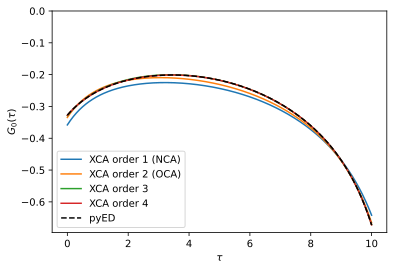

In [8]:
def label(order):
    return f'XCA order {order}' + {1: ' (NCA)', 2: ' (OCA)'}.get(order, '')

for order, r in results.items():
    oplotr(r['G_tau'], label=label(order))
oplotr(g_tau_ed, 'k--', label='pyED')

plt.xlabel(r'$\tau$'); plt.ylabel(r'$G_0(\tau)$'); plt.ylim(top=0); plt.legend(loc='best');

## Dynamic density correlation

At first order the density correlator contains no interaction vertex, and its deviation from the reference is larger than for $G_0(\tau)$. The vertex corrections at higher orders bring $\chi(\tau)$ progressively closer to the exact result, although it converges more slowly than $G_0(\tau)$.

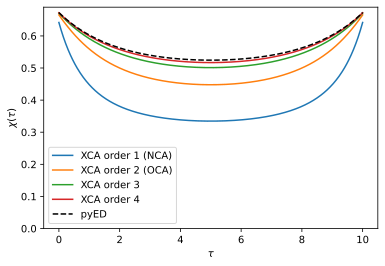

In [9]:
for order, r in results.items():
    oplotr(r['chi_tau'], label=label(order))
oplotr(chi_tau_ed, 'k--', label='pyED')

plt.xlabel(r'$\tau$'); plt.ylabel(r'$\chi(\tau)$'); plt.ylim(bottom=0); plt.legend(loc='best');

In [10]:
for order, r in results.items():
    G_err = np.max(np.abs(r['G_tau'].data - g_tau_ed.data))
    chi_err = np.max(np.abs(r['chi_tau'].data - chi_tau_ed.data))
    print(f'order {order}: max|G_0 - G_0^ED| = {G_err:2.2E}, max|chi - chi^ED| = {chi_err:2.2E}')

order 1: max|G_0 - G_0^ED| = 3.08E-02, max|chi - chi^ED| = 1.90E-01
order 2: max|G_0 - G_0^ED| = 1.37E-02, max|chi - chi^ED| = 7.66E-02
order 3: max|G_0 - G_0^ED| = 1.51E-03, max|chi - chi^ED| = 2.33E-02
order 4: max|G_0 - G_0^ED| = 3.69E-04, max|chi - chi^ED| = 7.57E-03


The deviation from the exact reference decreases with every expansion order, for $G_0(\tau)$ faster than for $\chi(\tau)$.